# Sweden traffic (ÅDT) panel — investigating `traffic preprocess` / `traffic assemble`

**Source.** NVDB's `Trafik` product (Average Daily Traffic, CNOSSOS-EU-ready
time-of-day × vehicle-class splits), Covariate Cluster C. Manually
downloaded via Lastkajen as one or more `Betraktelsedatum`-dated
Sverigefiler orders — **each order is a genuinely different historical
snapshot of NVDB's per-segment `[valid_from, valid_to)` measurement
history**, not redundant copies of the same "current" data. `preprocess`
unions every order found under `raw/`; `assemble` matches each school to
its nearest segment and attaches that segment's *full* recovered window
history (not just the current one).

**What this notebook is.** A verification pass reproducing the real
2026-09-16 correction documented in
[`docs/data/sweden/traffic/README.md`](../../../docs/data/sweden/traffic/README.md)'s
"Correction" section: an earlier same-session test wrongly concluded
`Betraktelsedatum` orders don't return real historical data (filtering to
`valid_to == 99991231` only); a user-provided real example proved
otherwise. This notebook shows a real multi-window element from the actual
persisted data, then the school-matching + panel-level join coverage this
now supports.


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

DATA = ROOT / "data" / "sweden"

print("root:", ROOT)

TRAFFIC = DATA / "traffic"
print("raw orders:", [p.name for p in (TRAFFIC / "raw").iterdir() if p.is_dir()])
print("processed:", list((TRAFFIC / "processed").glob("*")))
print("assembled:", list((TRAFFIC / "assembled").glob("*")))


root: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution
raw orders: ['Traffic_220914_Geopackage_653449', 'Traffic_190101_Geopackage_653568', 'Traffic_070101_Geopackage_653558', 'Traffic_990101_Geopackage_653550', 'Traffic_150101_Geopackage_653566', 'Traffic_260916_Geopackage_653409', 'Traffic_110101_Geopackage_653562', 'Traffic_030101_Geopackage_653555']
processed: [PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/sweden/traffic/processed/traffic.parquet')]
assembled: [PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/sweden/traffic/assembled/school_traffic.parquet')]


## 1. Load the unioned, full-history `traffic.parquet`


In [2]:
traffic = pd.read_parquet(TRAFFIC / "processed" / "traffic.parquet")
print(f"{len(traffic):,} rows, {traffic['element_id'].nunique():,} distinct element_id")

years = traffic["valid_from"].astype(str).str[:4].astype(int)
print("valid_from year range:", years.min(), "-", years.max())

windows_per_element = traffic.groupby("element_id").size()
multi = (windows_per_element >= 2).sum()
print(f"elements with 2+ recovered historical windows: {multi:,} of {len(windows_per_element):,} "
      f"({multi / len(windows_per_element):.1%})")


295,696 rows, 77,485 distinct element_id
valid_from year range: 1984 - 2026
elements with 2+ recovered historical windows: 58,566 of 77,485 (75.6%)


## 2. A real multi-window element — full history, not a flat current-only snapshot

Picks whichever element has the most recovered windows and shows its own
`[valid_from, valid_to)` history directly, the same kind of check that
caught the original bug (a stale single-snapshot version would only ever
show one row here).


In [3]:
busiest_element = windows_per_element.idxmax()
history = traffic[traffic["element_id"] == busiest_element].sort_values("valid_from")
print(f"element_id {busiest_element!r}: {len(history)} recovered windows")
history[["valid_from", "valid_to", "adt_samtliga_fordon", "matarsperiod", "matmetod"]]


element_id '1000:79316': 82 recovered windows


,valid_from,valid_to,adt_samtliga_fordon,matarsperiod,matmetod
295572,19970101,19990901,6507.0,199301.0,Stickprovsmätning
295573,19970101,19990901,6507.0,199301.0,Stickprovsmätning
295328,19970101,19990901,5338.0,199701.0,Stickprovsmätning
295327,19970101,19990901,5338.0,199701.0,Stickprovsmätning
295570,19970101,19990327,5700.0,199701.0,Stickprovsmätning
...,...,...,...,...,...
251821,20250101,99991231,10230.0,202501.0,Stickprovsmätning
251817,20250101,99991231,11736.0,202501.0,Stickprovsmätning
251820,20250101,99991231,11736.0,202501.0,Stickprovsmätning
251908,20250101,99991231,13252.0,202501.0,Stickprovsmätning


## 3. School ↔ traffic matching + full window history (`assemble`)


In [4]:
school_traffic = pd.read_parquet(TRAFFIC / "assembled" / "school_traffic.parquet")
matched = school_traffic.dropna(subset=["element_id"])
n_schools = school_traffic["skolenhetskod"].nunique()
n_matched_schools = matched["skolenhetskod"].nunique()
print(f"{n_matched_schools:,} of {n_schools:,} schools ({n_matched_schools / n_schools:.1%}) matched to a Trafik segment")
print(f"{len(matched):,} (school, window) history rows -- median "
      f"{matched.groupby('skolenhetskod').size().median():.0f} windows per matched school")
print("median match distance (m):", school_traffic.dropna(subset=['dist_m'])['dist_m'].median())


8,629 of 9,520 schools (90.6%) matched to a Trafik segment
44,737 (school, window) history rows -- median 3 windows per matched school
median match distance (m): 237.7463882162972


## 4. Panel-level match coverage over time (the interval-overlap join)


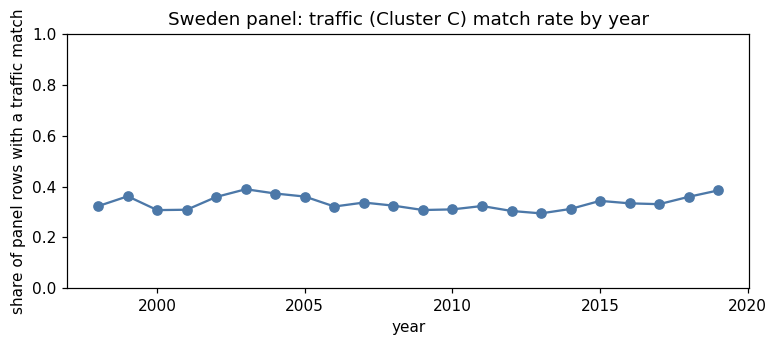

overall match rate: 33.5%


In [5]:
from src.regions.sweden.sources.panel.shared import assembled_panel_path

panel = pd.read_parquet(assembled_panel_path())
by_year = panel.groupby("year")["traffic_adt_samtliga_fordon"].apply(lambda s: s.notna().mean())

fig, ax = plt.subplots(figsize=(8, 3))
by_year.plot(ax=ax, marker="o", color=BLUE)
ax.set_ylabel("share of panel rows with a traffic match")
ax.set_title("Sweden panel: traffic (Cluster C) match rate by year")
ax.set_ylim(0, 1)
plt.show()

print(f"overall match rate: {panel['traffic_adt_samtliga_fordon'].notna().mean():.1%}")


## Summary

- `traffic.parquet` genuinely unions multiple `Betraktelsedatum` orders
  into real per-segment historical windows — a real multi-window element
  is directly inspectable above, not just claimed in the docstring.
- The school↔segment spatial match and the full-history broadcast both run
  end-to-end against the real persisted data.
- The final panel's year-by-year match-rate line is the direct,
  reproducible consequence of `panel/assemble.py::attach_traffic`'s
  interval-overlap join picking, for each outcome row's own year, whichever
  recovered window (if any) actually covers it.
